# Week 6 part 1: the SVD for 2 by 2 matrices

This notebook has two parts. In the first part, you'll work through the full Singular Value Decomposition for 2x2 matrices for the first time. In a second part, you'll see the SVD for general matrices.

The first part is more exploratory. The second part contains detailed statements that you can use for reference.

Goals for this week:

1. Construct a $2\times 2$ matrix $M$ as a product of three matrices $H$, $S$, and $C.T$ with these properties
    1. The columns of $C$ are an orthonormal basis $c0, c1$
    2. $S$ is a diagonal matrix with positive entries $s_0, s_1$ on the diagonal.
    3. The colums of $H$ are an orthonormal basis $h0, h1$
    4. $M$ sends the unit circle to an ellipse with axes of length $s_0, s_1$ along the vectors $h_0$ and $h_1$.
    5. $M$ sends $c_0$ to the axis $s_0 * h_0$ and $c_1$ to the axis $s_1 * h_1$
2. Describe the full matrices SVD and know how to use Python to find the SVD of a square matrix $M$.
3. Describe the full matrices SVD and know how to use Python to find the SVD of a not-necessarily square matrix $M$. 
4. Be able to reconstruct a square or non-square matrix from its SVD
3. Define the rank of a matrix $M$ and say how to find it interms of the SVD
4. Describe the compact SVD and be able to find the compact SVD of a matrix, square or nonsquare, in Python
5. If $H,s,CT$ is the SVD of the matrix $M$, be able to describe the effect of $M$ in terms of the singular values $s$, the rows of $CT$, and the columns of $H$.

There are some do-its at the end of each part.


## Initialization Cells

In [1]:
# This initialization cell imports standard python packages

import numpy as np
import numpy.linalg as la

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors

import math
import scipy

import scipy.misc




/tmp/ipykernel_659/3953858590.py:13: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  import scipy.misc


In [2]:
# This initialization cell is for material special to Linear Algebra for Data Science

# This function sets up a standard 2D plot for demonstrations involving 2D vectors as arrows.
# Some key features

#  -- You can specify more than one plot. If you call LADS2DSquare(n), you get n plots side-by-side
#     If you call LADS2DSquare(c,r) you get c columns and r rows. Don't do that, instead, use the arguemtns as described below.
#  -- each plot is square and the aspect ratio is set to 1,
#     for true geometry: for example, orthogonal vectors will appear to be perpendicular
#  -- gridlines at integer points
#  -- the origin in the center
#  -- the line x=0 and the line y = 0 are prominent
#
#  -- If you ask for only one plot, you'll get a single instance. In other cases you'll get a 1D array
#     or a 2D array of Axes instances.

# You can set the low and high values of the plot

# Returns two things: the matplotlib figure and axes instances


def LADS2DSquare(ncols=1, nrows=1, xlow=-2., xhigh=2.):
    LADS2Dfig = plt.figure(figsize=[ncols * 6., nrows * 6.])
    nplot = nrows * ncols

    if nplot == 1:
        LADS2Dax = LADS2Dfig.add_axes([0, 0, 1, 1])
        LADS2Dax.set_xlim(xlow, xhigh)
        LADS2Dax.set_ylim(xlow, xhigh)
        LADS2Dax.set_aspect('equal')

        # Add x and y axes crossing at origin (0.0)
        LADS2Dax.axhline(y=0, color='gray')
        LADS2Dax.axvline(x=0, color='gray')

        # Set ticks to a reasonable number
        LADS2Dax.set_xticks(np.arange(math.ceil(xlow), math.floor(xhigh) + 1))
        LADS2Dax.set_yticks(np.arange(math.ceil(xlow), math.floor(xhigh) + 1))

        LADS2Dax.grid(True)

        return LADS2Dfig, LADS2Dax

# else if nplot>1...
    LADS2Dax = LADS2Dfig.subplots(nrows, ncols)
    if min(nrows, ncols) == 1:
        for i in range(nplot):
            LADS2Dax[i].set_xlim(xlow, xhigh)
            LADS2Dax[i].set_ylim(xlow, xhigh)
            LADS2Dax[i].set_aspect('equal')

            # Add x and y axes crossing at origin (0.0)
            LADS2Dax[i].axhline(y=0, color='gray')
            LADS2Dax[i].axvline(x=0, color='gray')

            # Set ticks to a reasonable number
            LADS2Dax[i].set_xticks(
                np.arange(math.ceil(xlow),
                          math.floor(xhigh) + 1))
            LADS2Dax[i].set_yticks(
                np.arange(math.ceil(xlow),
                          math.floor(xhigh) + 1))
            LADS2Dax[i].grid(True)
# end for

        return LADS2Dfig, LADS2Dax
# end "if nplot>1"

#else if nrows>1 and ncols > 1...

    for i, j in np.ndindex(nrows, ncols):
        LADS2Dax[i, j].set_xlim(xlow, xhigh)
        LADS2Dax[i, j].set_ylim(xlow, xhigh)
        LADS2Dax[i, j].set_aspect('equal')

        # Add x and y axes crossing at origin (0.0)
        LADS2Dax[i, j].axhline(y=0, color='gray')
        LADS2Dax[i, j].axvline(x=0, color='gray')

        # Set ticks to a reasonable number
        LADS2Dax[i, j].set_xticks(
            np.arange(math.ceil(xlow),
                      math.floor(xhigh) + 1))
        LADS2Dax[i, j].set_yticks(
            np.arange(math.ceil(xlow),
                      math.floor(xhigh) + 1))
        LADS2Dax[i, j].grid(True)

    return LADS2Dfig, LADS2Dax


# This method draws arrows on an matplotlib axes class.

# this is a generic method, designed to be added to the matplotlib Axes class
# The hsv color map is good for drawing circles of vectors (where the end of the list will be near the beginning). Other colormaps may be better
# for arbitrary lists. See https://matplotlib.org/stable/tutorials/colors/colormaps.html


def LADS2DDrawVectorList(self, VectorList, cmap=cm.hsv,columns=False):
    #norm.autoscale(0,len(VectorList))
    VList = VectorList
    if not columns: 
        VList = VectorList.T
        
    zeroes = np.zeros(len(VList[0]))
    self.quiver(zeroes,
                zeroes,
                *VList,
                color=cmap(np.linspace(0, 1, len(VList[0]),endpoint=False)),
                angles='xy',
                scale_units='xy',
                scale=1)


# This command adds the method above to Axes
plt.Axes.LADS2DDrawVectorList = LADS2DDrawVectorList

# these methods draws a single arrow in 2D and 3D


def LADS2DDrawVector(self, Vector, col='g', TailAt=np.array([0., 0.])):
    self.quiver([TailAt[0]], [TailAt[1]], [Vector[0]], [Vector[1]],
                color=col,
                angles='xy',
                scale_units='xy',
                scale=1)


plt.Axes.LADS2DDrawVector = LADS2DDrawVector


# Creates a 2D rotation matrix: rotates by the angle theta, specified in radians, counterclockwise


def RotationMatrix2D(theta):
    return np.array([[np.cos(theta), -np.sin(theta)],
                     [np.sin(theta), np.cos(theta)]])



# This produces the j element of the standard basis in dimension d

def LADSStdBasis(j,*,dim):
    if j<0 or j>=dim:
        print("This basis element is not defined")
        return
    e = np.zeros(dim)
    e[j] = 1
    return e
    

## End of Initialization Cells

# The SVD for 2 by 2 matrices

In week 5, you learned how to set up a matrix that sends one orthonormal basis to another. Let's remember about that. First we'll set up an 2D orthonormal basis $b0, b1$ that are the columns of a matrix $B$.

B0 = [0.70710678 0.70710678]
b0 =  [0.70710678 0.70710678]
B1 = [-0.70710678  0.70710678]
b1 =  [-0.70710678  0.70710678]


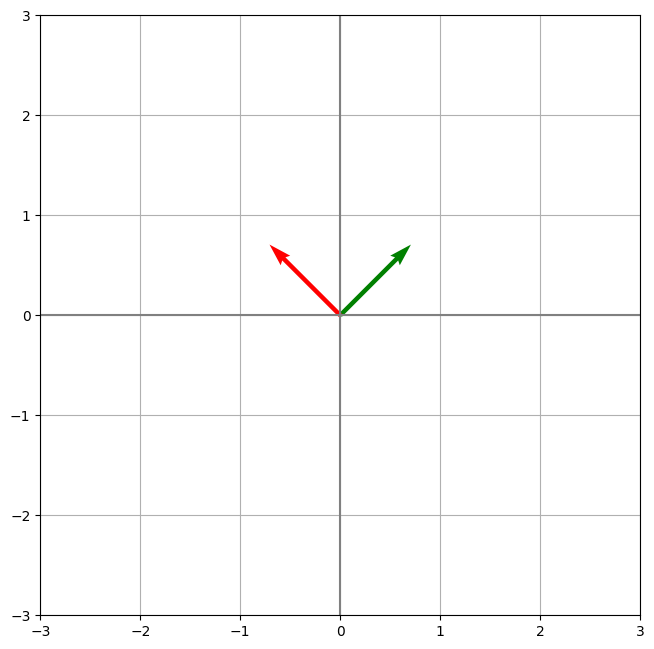

In [3]:
# First we'll set up one orthonormal basis b0, b1 

e0 = LADSStdBasis(0,dim=2)
e1 = LADSStdBasis(1,dim=2)
B = RotationMatrix2D(np.pi/4)
b0 = B@e0
b1 = B@e1

# Remember that when we apply a matrix B to the standard basis e0 and e1, the result are the the 0 and 1
# columns of the matrix. For good measure, let's check that.

print("B0 =",B[:,0])
print("b0 = ",b0)
print("B1 =",B[:,1])
print("b1 = ",b1)

# Now let's draw b0 and b1 on a matplotlib axes

fig,ax=LADS2DSquare(xlow=-3,xhigh=3)
ax.LADS2DDrawVector(b0)
ax.LADS2DDrawVector(b1,'red')



Now we'll set up another orthonormal basis $c0, c1$ that are the columns of a matrix $C$.

Text(0.5, 1.0, 'The orthonormal basis c0, c1')

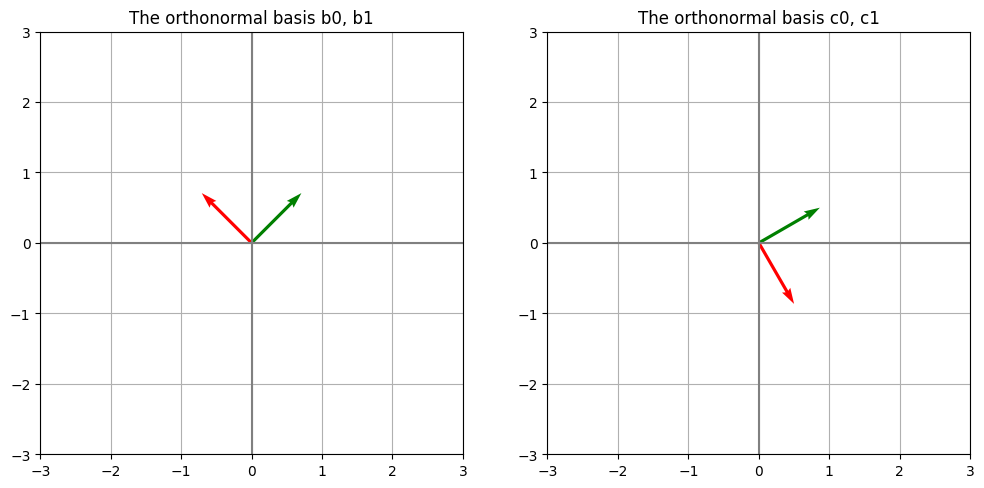

In [4]:

# here is another orthonormal basis C. This time we made c0 be clockwise from c1

c1 = RotationMatrix2D(-np.pi/3)@e0
c0 = RotationMatrix2D(-np.pi/3)@e1
C=np.array([c0,c1]).T

# Let's draw both of our bases next two each other

fig,ax=LADS2DSquare(ncols=2,xlow=-3,xhigh=3)
ax[0].LADS2DDrawVector(b0)
ax[0].LADS2DDrawVector(b1,'red')
ax[0].set_title('The orthonormal basis b0, b1')

ax[1].LADS2DDrawVector(c0)
ax[1].LADS2DDrawVector(c1,'red')
ax[1].set_title('The orthonormal basis c0, c1')

ASIDE: The orthonormal basis b0, b1 satisfies the **right hand rule:** if you rest your hand on $b0$ (the green arrow) so that you can move your fingers through an angle less than 180 degrees to reach the red arrow, then your your thumb points away from the picture. The basis $c0, c1$ does not. If you rest your right hand on the green arrow on the left ($c0$) so that you can move your fingers through an angle less than 180 degrees to reach the red arrow, your thumb points towards the screen. **Orthonormal bases do not have to satisfy the right hand rule.**

Now let's see that the matrix that sends $b0$ to $c0$ and $b1$ to $c1$ is just $C B^T$ or, in Python, $C@B.T$.

Text(0.5, 1.0, 'C@B.T applied to b0 and b1')

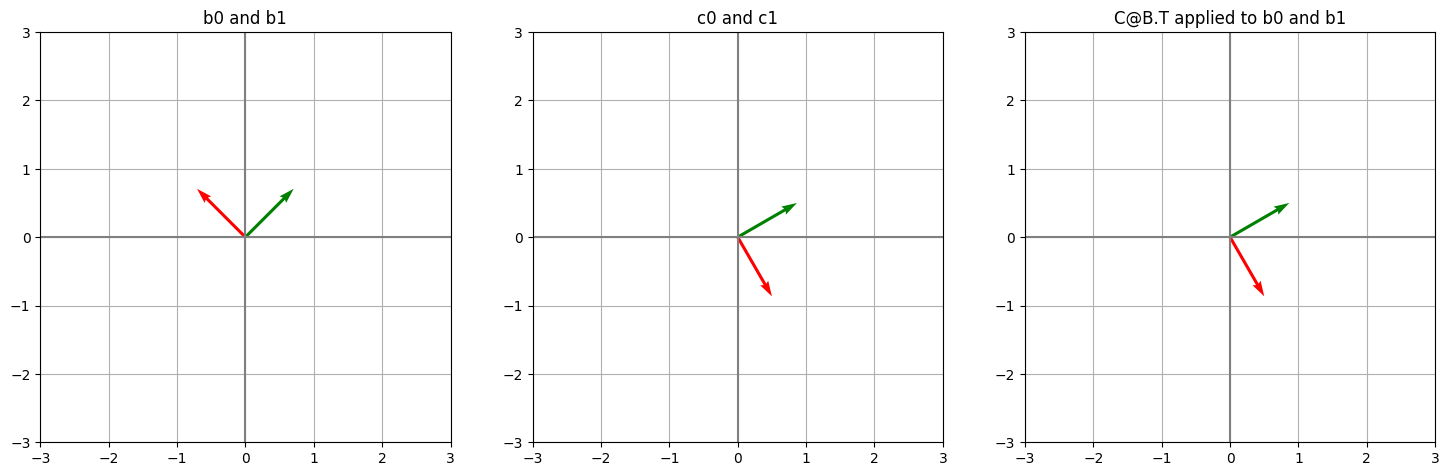

In [5]:
fig,ax=LADS2DSquare(ncols=3,xlow=-3,xhigh=3)

# on the left axes we'll draw b0 and b1.

ax[0].LADS2DDrawVector(b0)
ax[0].set_title("b0 and b1")
ax[0].LADS2DDrawVector(b1,'red')

# on the middle axes we'll draw c0 and c1.

ax[1].LADS2DDrawVector(c0)
ax[1].LADS2DDrawVector(c1,'red')
ax[1].set_title("c0 and c1")

# on the right axes we'll draw C @ B.T applied to b0 and b1

ax[2].LADS2DDrawVector(C@ B.T @ b0)
ax[2].LADS2DDrawVector(C@ B.T @ b1,'red')
ax[2].set_title("C@B.T applied to b0 and b1")

It's great that we can make a matrix that can send any orthonormal basis to any other. But we know from past experience that most matrices change the length of vectors: we have seen that 2 by 2 matrices in general send the unit circle to an ellipse. Here is the set-up we've been using to study that situation.

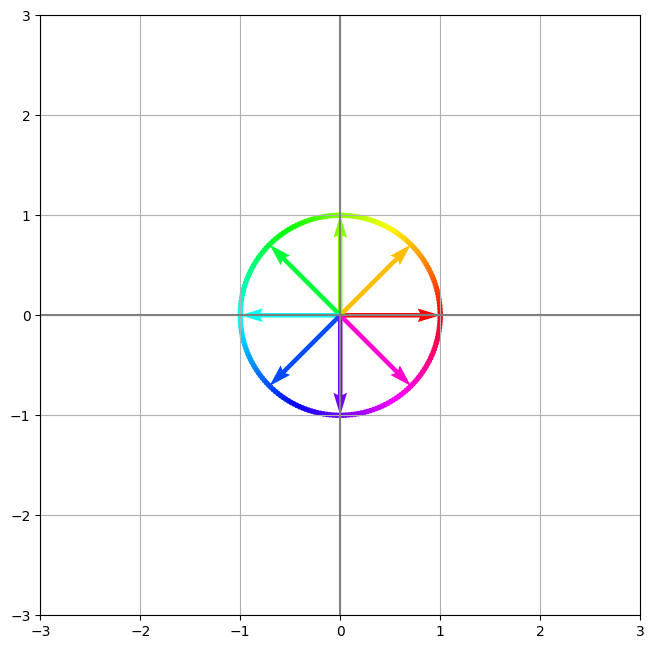

In [6]:

fig,ax=LADS2DSquare(xlow=-3,xhigh=3)


# np.linspace makes an array of numbers evenly spaced in the range you specify. 
# Here I've specified 8 numbers between 0 and 1. endpoint=false means that the last number is 7/8,
# so the array is [0,1/8,2/8,3/8,4/8,5/8,6/8,7/8]. I multiply by 2 pi, so actually 
# t is the array
#
# 0, pi/4, pi/2, 3pi/4, pi, 5pi/4, 3pi/2, 7pi/4.
#
# Those are all the multiples of 45 degrees on the circle


nwedges = 8
t = np.linspace(0.,1.,nwedges,endpoint=False) * 2.0 * np.pi  

# CircleArrows is an matrix whose first row is the cosines of the 8 angles t and whose second row is
# the sin of the 8 angles t. 

# Thus each column is a 2D unit vector, pointing in the 8 directions given by the angles t

CircleArrows = np.array([np.cos(t),np.sin(t)])

# now to the same thing with many more points to trace out the unit circle

# Create an array from 0 to 2pi with 200 points
theta = np.linspace(0, 2*np.pi, 200)

# UnitCirclePoints a matrix with 2 rows and 200 columns 
# Each column is a point on the unit circle.

UnitCirclePoints = np.array([np.cos(theta), np.sin(theta)])

# I want to color the cirlce when we draw it. colors is a list of values between 0 and 1, so it works as input
# to a matplotlib color map

colors  = theta/(2*np.pi)

# The method LADS2DDrawVectorList draws a list of vectors as arrows. You can specify a color map.
# The argument columns=True means that each column of CircleArrows is a 2D vector you want to draw

ax.LADS2DDrawVectorList(CircleArrows,cmap=cm.hsv,columns=True)

# the scatter method draws a scatter plot. You send it a list of x-values and a list of y-values, and it
# draws a blob at each (x,y) point on the list. Since our x values are the zero row of UnitCircle and
# our y values are the one row, we can use the unpacking operator * to make the zero row the first argument 
# and the one row the second argument.


# the colormap hsv has the same color at 1 as it does at zero, so the colors match up when the circle closes

ax.scatter(*UnitCirclePoints,marker=".",c=colors,cmap=cm.hsv)


We already know how to send the unit circle to an tilted ellipse. Let's make a matrix that sends the unit circle to the ellipse lying along the line 60 degrees (or $\pi/3$ radians) clockwise from the x-axis, with long axis radius 3 and short axis radius 0.8. 
We can do that by first stretching along the x and y axes, and then rotating clockwise by $\pi/3$ radians. 

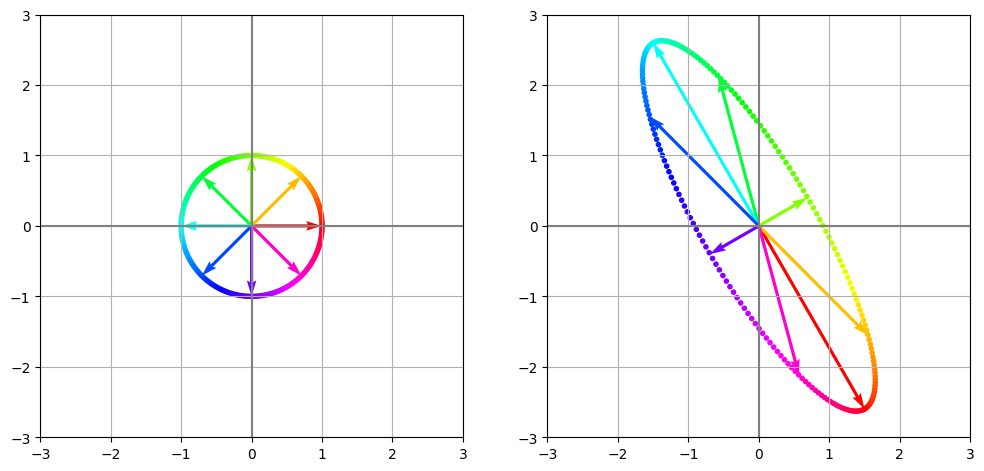

In [7]:
fig,ax=LADS2DSquare(ncols=2,xlow=-3,xhigh=3)

ax[0].LADS2DDrawVectorList(CircleArrows,columns=True)
ax[0].scatter(*UnitCirclePoints,marker=".",c=colors,cmap=cm.hsv)

# D stretches by 3 along x and 0.8 along y
D = np.diag([3.,0.8])
# R rotates clockwise by pi/3 radians
R = RotationMatrix2D(-np.pi/3) 

# M does D then R.

M = R @ D

ax[1].LADS2DDrawVectorList(M@CircleArrows,columns=True)
ax[1].scatter(*(M@UnitCirclePoints),marker=".",c=colors,cmap=cm.hsv)

The shape is as general as we've seen, but there is one more thing we can ask the matrix to do. Not every matrix sends the red arrow on the left (the standard basis vector $[0,1]$) to the long axis. For example, let's try to write a matrix that sends the dark blue arrow to the long axis and the magenta arrow perpendicular to it to the short axis. 

The dark blue arrow is at 225 degrees or $5 \pi/4$ radians, and the magenta arrow is at 315 degrees or $7 \pi/4$ radians. Together they form an orthonormal basis. You can get to it by rotating the standard basis $5 \pi/4$ radians counterclockwise. Let's check that.


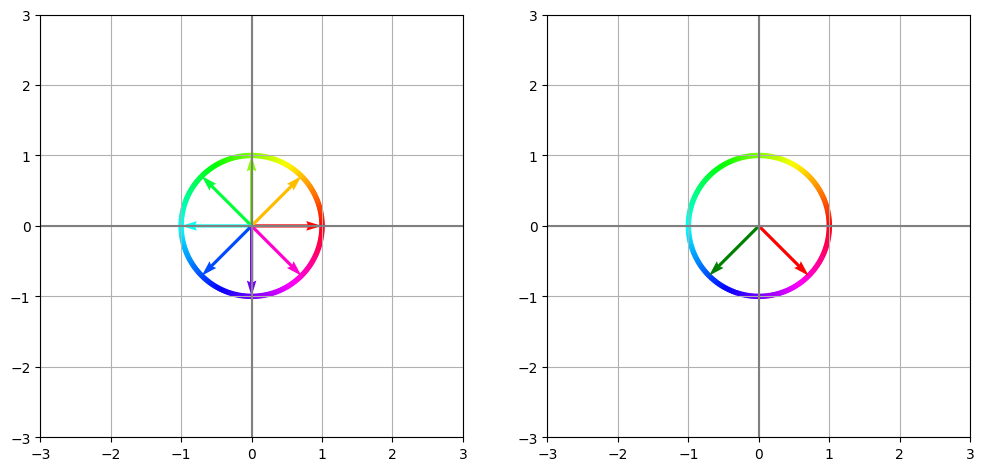

In [8]:
fig,ax = LADS2DSquare(ncols=2,xlow=-3,xhigh=3)

ax[0].LADS2DDrawVectorList(CircleArrows,columns=True)
ax[0].scatter(*UnitCirclePoints,marker=".",c=colors,cmap=cm.hsv)


# C rotates clockwise by 5pi/4 radians counterclockwise
C = RotationMatrix2D(5*np.pi/4) 

e0 = LADSStdBasis(0,dim=2)
e1 = LADSStdBasis(1,dim=2)

c0 = C@e0
c1 = C@e1

#ax[1].LADS2DDrawVectorList(CircleArrows,columns=True)
ax[1].scatter(*UnitCirclePoints,marker=".",c=colors,cmap=cm.hsv)
ax[1].LADS2DDrawVector(c0,'green')
ax[1].LADS2DDrawVector(c1,'red')



Now let's make a matrix that transforms the unit circle on the left into an ellipse with long axis along the 60 degree line, with the blue arrow sent to the long axis and the green arrow sent to the short axis. We'll make the matrix in three steps:

1. We'll send the blue arrow $c0$ to $e0$ and the magenta arrow $c1$ to $e1$. Since $c0$ and $c1$ are an orthonormal basis, if $C$ is the matrix with columns $c0$ and $c1$, then the matrix we want is $C.T$!

2. Next we'll stretch by a factor of 3 along the e0 direction (the x-axis) and by 0.8 along the e1 direction (the y-axis). The matrix to do that is the diagonal matrix $S$ with entries $3.$ and $0.8$.

3. Finally, we'll rotate clockwise by $\pi/3$ radians or 60 degrees. The matrix to do that is $R$.

The matrix that does all these three things in order is the product $R @ D @ C.T$.

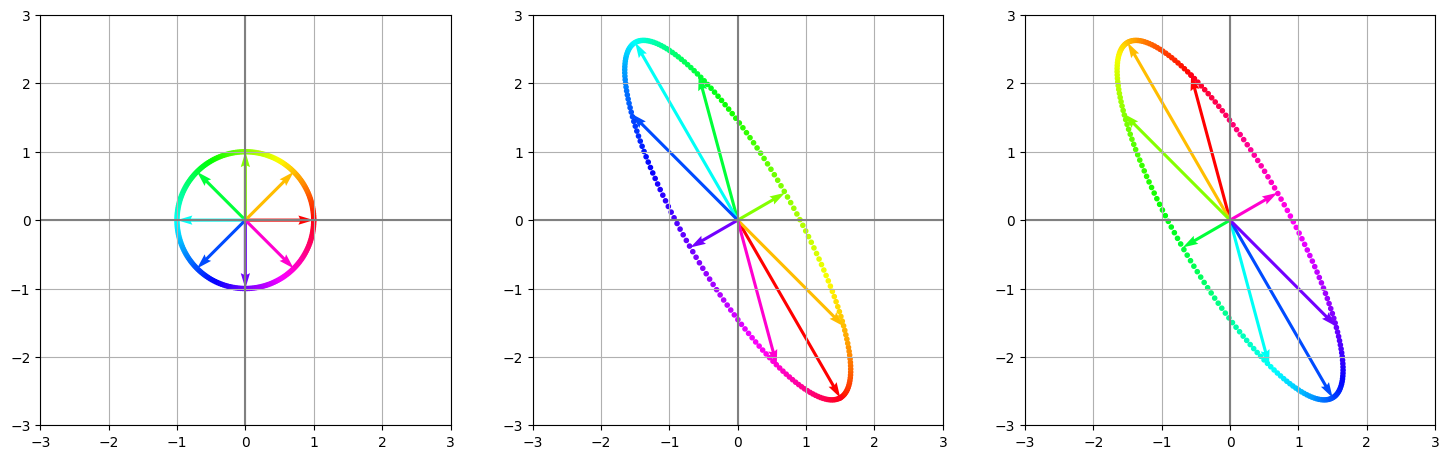

In [9]:
fig,ax = LADS2DSquare(ncols=3,xlow=-3,xhigh=3)

ax[0].LADS2DDrawVectorList(CircleArrows,columns=True)
ax[0].scatter(*UnitCirclePoints,marker=".",c=colors,cmap=cm.hsv)

# C sends e0 the the blue arrow and e1 to the magenta arrow. 
# C.T reverses this and sends the blue arrow to e0 and the magenta arrow to e1.
C=RotationMatrix2D(5*np.pi/4)

# S stretches by 3 along x and 0.8 along y
S = np.diag([3.,0.8])

# R rotates clockwise by pi/3 radians (clockwise is the reason for the minus sign)
R = RotationMatrix2D(-np.pi/3) 

# M does S then R.
M = R @ S

ax[1].LADS2DDrawVectorList(M@CircleArrows,columns=True)
ax[1].scatter(*(M@UnitCirclePoints),marker=".",c=colors,cmap=cm.hsv)


T = R @ S @ C.T

ax[2].LADS2DDrawVectorList(T@CircleArrows,columns=True)
ax[2].scatter(*(T@UnitCirclePoints),marker=".",c=colors,cmap=cm.hsv)



It turns out that this is a general recipe for writing down any 2 by 2 matrix: figure out what ellipse you want to get, in particular
1. How long are its long and short axes? This tells you the entries of a diagonal matrix $S$. (I'm using $S$ for "stretch" or "singular values" instead of $D$ for "diagonal") 
2. What direction do you want the long and short axes to point? The unit-length vectors in these directions 
give you a matrix $H$ with orthonormal columns. 
3. What pair of orthonormal vectors do you want to send to the long and short axes?
The answer to this question gives another matrix with orthonormal columns, $C$. 
The matrix you need at the end is then just $H S C^T$ or in Python $H@S@C.T$.

The fact that this procedure allows you to construct every possible 2 by 2 matrix is an example of the "Singular Value Decomposition" or SVD.

In [10]:
print(T)
print(R)
print(S)
print(C.T)
print(np.allclose(T,R@S@C.T))

[[-0.57076222 -1.55055812]
 [ 2.11996002  1.55427459]]
[[ 0.5        0.8660254]
 [-0.8660254  0.5      ]]
[[3.  0. ]
 [0.  0.8]]
[[-0.70710678 -0.70710678]
 [ 0.70710678 -0.70710678]]
True


In [11]:
H,d,AT = la.svd(T)
print(H)
print(d)
print(AT)

[[-0.5        0.8660254]
 [ 0.8660254  0.5      ]]
[3.  0.8]
[[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]]


In the Do-its for this part, you'll repeat the steps above with a different collection of choices.

#### **Do it:** 
1. Choose an angle in radians for your rotated ellipse, between $0$ and $2\pi$. For good visual effect, do not choose a multiple of $\pi/2$ (90 degrees), and do not choose the angle we just used $\pi/3$ (60 degrees). One good approach is to choose a fraction between $0$ and $1$, and multiply it by $2\pi4$ or `2*np.pi`. Another possible approach is to choose a random number between $0$ and $2 \pi$. Choose lengths for the long radius and short radius of your ellipse. For good visual effect, don't make the radii equal (you'll get a circle). 

3. Make the diagonal matrix $S$ that stretches the unit circle to the ellipse you want, and the matrix $R$ that rotates the ellipse to the position you want it.

4. Make the product of $S$ and $R$ that transforms the unit circle with its embedded arrows into your rotated, stretched ellipse. Draw this using matplotlib.


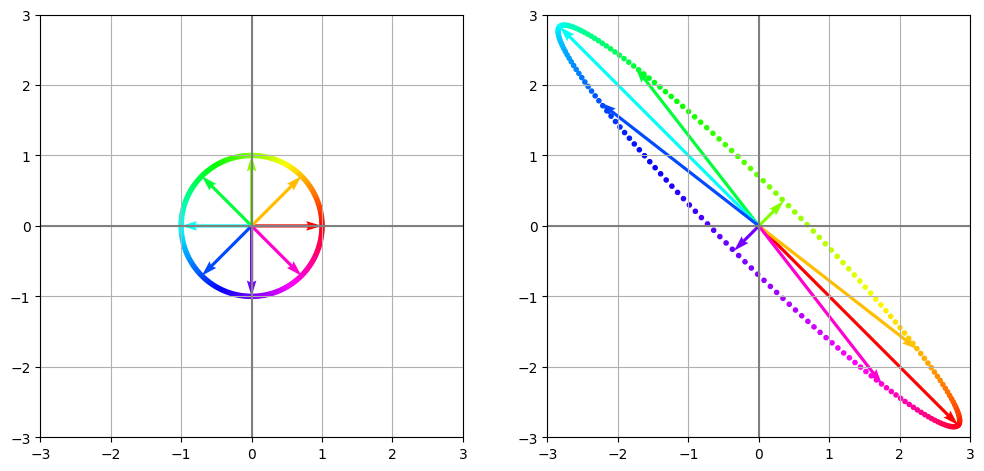

In [12]:
fig,ax=LADS2DSquare(ncols=2,xlow=-3,xhigh=3)

ax[0].LADS2DDrawVectorList(CircleArrows,columns=True)
ax[0].scatter(*UnitCirclePoints,marker=".",c=colors,cmap=cm.hsv)


D = np.diag([4.,0.5])

R = RotationMatrix2D(-np.pi/4) 

# M does D then R.

M = R @ D

ax[1].LADS2DDrawVectorList(M@CircleArrows,columns=True)
ax[1].scatter(*(M@UnitCirclePoints),marker=".",c=colors,cmap=cm.hsv)

#### Leave this cell for the grader

Now we'll build the matrix that transforms the unit circle into your ellipse and sends the green arrow at 135 degrees to the long axis, and the blue arrow at 225 degrees to the short axis.

#### **Do it:** 
135 degrees is $3\pi/4$ radians, and 225 degrees is $5\pi/4$ radians. Make a matrix $C$ that takes the standard basis vector $e0$ to the unit length vector at $3\pi/4$ radians, and the standard basis vector $e1$ to the unit length vector at $5 \pi/4$ radians. Display the vectors $c0=C@e0$ and $c1=C@e1$ to show that they are where they should be.

Matrix C:
 [[-0.70710678 -0.70710678]
 [ 0.70710678 -0.70710678]]
C @ e0 = [-0.70710678  0.70710678]
C @ e1 = [-0.70710678 -0.70710678]


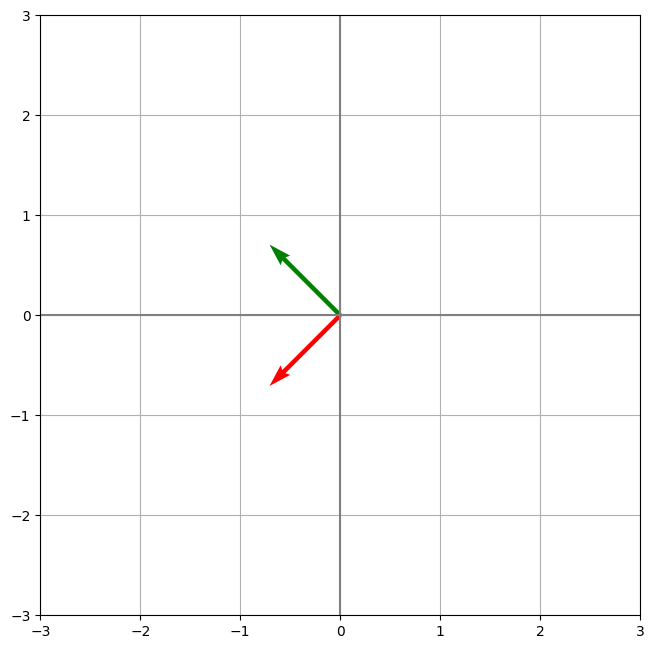

In [13]:
# you can put your work in this code cell
fig,ax=LADS2DSquare(xlow=-3,xhigh=3)
e0 = 3* np.pi / 4
e1 = 5* np.pi / 4
c0 = np.array([np.cos(e0), np.sin(e0)])
c1 = np.array([np.cos(e1), np.sin(e1)])

C = np.column_stack((c0, c1))

# Define standard basis vectors
e0 = np.array([1, 0])
e1 = np.array([0, 1])

# Verify the mapping
c0_result = C @ e0
c1_result = C @ e1

# Print everything
print("Matrix C:\n", C)
print("C @ e0 =", c0_result)
print("C @ e1 =", c1_result)
ax.LADS2DDrawVector(c0)
ax.LADS2DDrawVector(c1,'red')

#### Leave this cell for the grader

#### **Do it:**
Take the vectors $c0$ and $c1$ from the previous Do It. Apply $C^T$ or in Pyton $C.T$ to $c0$ and $c1$, and check that you get back the unit coordinate vectors $e0$ and $e1$. You can either just print the values of $C.T$ applied to $c0$ and $c1$, or you can draw them using matplotlib.

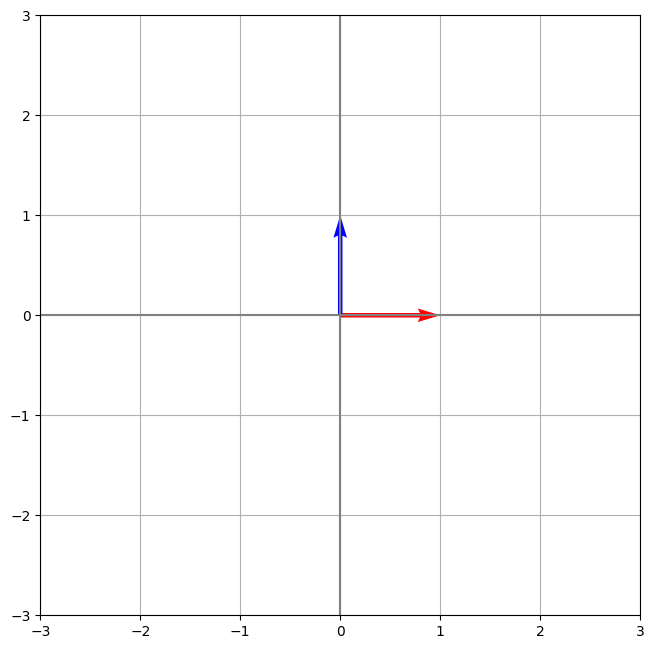

In [14]:
fig,ax=LADS2DSquare(xlow=-3,xhigh=3)

c0_back = C.T @ c0
c1_back = C.T @ c1

ax.LADS2DDrawVector(c0_back, "red")
ax.LADS2DDrawVector(c1_back, "blue")

#### Leave this cell for the grader.

#### **Do it:**
Now apply the matrix $R @ D @ C.T$ to the unit circle, and draw the result in matplotlib. Check that you get your ellipse, with the green arrow on the long axis and the blue arrow on the short axis.

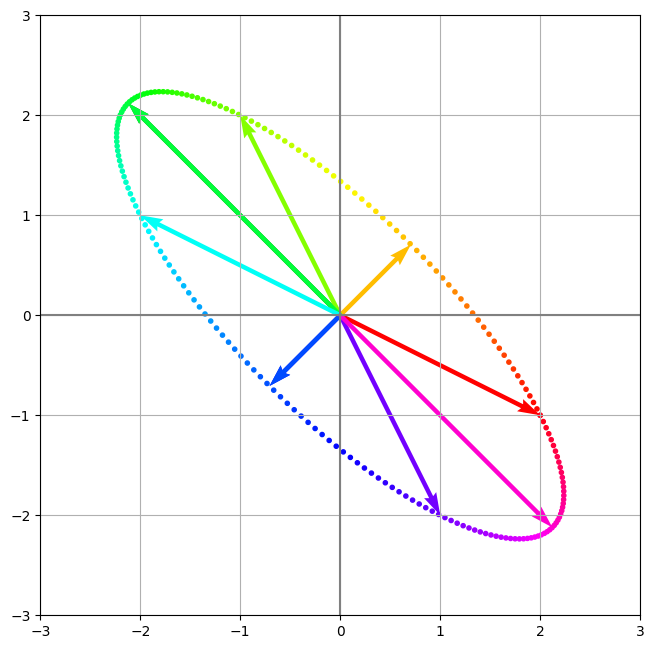

In [15]:

theta = np.linspace(0, 2 * np.pi, 200)
circle = np.vstack((np.cos(theta), np.sin(theta)))
theta0 = 3 * np.pi / 4
theta1 = 5 * np.pi / 4
c0 = np.array([np.cos(theta0), np.sin(theta0)])
c1 = np.array([np.cos(theta1), np.sin(theta1)])
C = np.column_stack((c0, c1))


D = np.diag([3, 1]) 

R = C


T = R @ D @ C.T

ellipse = T @ circle


green_arrow = R @ np.array([3, 0])  
blue_arrow = R @ np.array([0, 1])   
fig,ax=LADS2DSquare(xlow=-3,xhigh=3)

ax.LADS2DDrawVector(green_arrow, "green")
ax.LADS2DDrawVector(blue_arrow, "blue")
ax.LADS2DDrawVectorList(T@CircleArrows,columns=True)
ax.scatter(*(T@UnitCirclePoints),marker=".",c=colors,cmap=cm.hsv)

#### Leave this cell for the grader.

# Week 6 part 2: introduction to the general SVD

In this notebook we'll describe the SVD in general. This notebook is more of a reference than some of our other notebooks. 

## Initialization Cells

In [16]:
# This initialization cell imports standard python packages

import numpy as np
import numpy.linalg as la

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors


import math
import scipy

rng = np.random.default_rng()

In [17]:
# This initialization cell is for material special to Linear Algebra for Data Science

# This function sets up a standard 2D plot for demonstrations involving 2D vectors as arrows.
# Some key features

#  -- You can specify more than one plot. If you call LADS2DSquare(n), you get n plots side-by-side
#     If you call LADS2DSquare(c,r) you get c columns and r rows. Don't do that, instead, use the arguemtns as described below.
#  -- each plot is square and the aspect ratio is set to 1,
#     for true geometry: for example, orthogonal vectors will appear to be perpendicular
#  -- gridlines at integer points
#  -- the origin in the center
#  -- the line x=0 and the line y = 0 are prominent
#
#  -- If you ask for only one plot, you'll get a single instance. In other cases you'll get a 1D array
#     or a 2D array of Axes instances.

# You can set the low and high values of the plot

# Returns two things: the matplotlib figure and axes instances


def LADS2DSquare(ncols=1, nrows=1, xlow=-2., xhigh=2.):
    LADS2Dfig = plt.figure(figsize=[ncols * 6., nrows * 6.])
    nplot = nrows * ncols

    if nplot == 1:
        LADS2Dax = LADS2Dfig.add_axes([0, 0, 1, 1])
        LADS2Dax.set_xlim(xlow, xhigh)
        LADS2Dax.set_ylim(xlow, xhigh)
        LADS2Dax.set_aspect('equal')

        # Add x and y axes crossing at origin (0.0)
        LADS2Dax.axhline(y=0, color='gray')
        LADS2Dax.axvline(x=0, color='gray')

        # Set ticks to a reasonable number
        LADS2Dax.set_xticks(np.arange(math.ceil(xlow), math.floor(xhigh) + 1))
        LADS2Dax.set_yticks(np.arange(math.ceil(xlow), math.floor(xhigh) + 1))

        LADS2Dax.grid(True)

        return LADS2Dfig, LADS2Dax

# else if nplot>1...
    LADS2Dax = LADS2Dfig.subplots(nrows, ncols)
    if min(nrows, ncols) == 1:
        for i in range(nplot):
            LADS2Dax[i].set_xlim(xlow, xhigh)
            LADS2Dax[i].set_ylim(xlow, xhigh)
            LADS2Dax[i].set_aspect('equal')

            # Add x and y axes crossing at origin (0.0)
            LADS2Dax[i].axhline(y=0, color='gray')
            LADS2Dax[i].axvline(x=0, color='gray')

            # Set ticks to a reasonable number
            LADS2Dax[i].set_xticks(
                np.arange(math.ceil(xlow),
                          math.floor(xhigh) + 1))
            LADS2Dax[i].set_yticks(
                np.arange(math.ceil(xlow),
                          math.floor(xhigh) + 1))
            LADS2Dax[i].grid(True)
# end for

        return LADS2Dfig, LADS2Dax
# end "if nplot>1"

#else if nrows>1 and ncols > 1...

    for i, j in np.ndindex(nrows, ncols):
        LADS2Dax[i, j].set_xlim(xlow, xhigh)
        LADS2Dax[i, j].set_ylim(xlow, xhigh)
        LADS2Dax[i, j].set_aspect('equal')

        # Add x and y axes crossing at origin (0.0)
        LADS2Dax[i, j].axhline(y=0, color='gray')
        LADS2Dax[i, j].axvline(x=0, color='gray')

        # Set ticks to a reasonable number
        LADS2Dax[i, j].set_xticks(
            np.arange(math.ceil(xlow),
                      math.floor(xhigh) + 1))
        LADS2Dax[i, j].set_yticks(
            np.arange(math.ceil(xlow),
                      math.floor(xhigh) + 1))
        LADS2Dax[i, j].grid(True)

    return LADS2Dfig, LADS2Dax


# This method draws arrows on an matplotlib axes class.

# this is a generic method, designed to be added to the matplotlib Axes class
# The hsv color map is good for drawing circles of vectors (where the end of the list will be near the beginning). Other colormaps may be better
# for arbitrary lists. See https://matplotlib.org/stable/tutorials/colors/colormaps.html


def LADS2DDrawVectorList(self, VectorList, cmap=cm.hsv,columns=False):
    #norm.autoscale(0,len(VectorList))
    VList = VectorList
    if not columns: 
        VList = VectorList.T
        
    zeroes = np.zeros(len(VList[0]))
    self.quiver(zeroes,
                zeroes,
                *VList,
                color=cmap(np.linspace(0, 1, len(VList[0]),endpoint=False)),
                angles='xy',
                scale_units='xy',
                scale=1)


# This command adds the method above to Axes
plt.Axes.LADS2DDrawVectorList = LADS2DDrawVectorList

# these methods draws a single arrow in 2D and 3D


def LADS2DDrawVector(self, Vector, col='g', TailAt=np.array([0., 0.])):
    self.quiver([TailAt[0]], [TailAt[1]], [Vector[0]], [Vector[1]],
                color=col,
                angles='xy',
                scale_units='xy',
                scale=1)


plt.Axes.LADS2DDrawVector = LADS2DDrawVector


# Creates a 2D rotation matrix: rotates by the angle theta, specified in radians, counterclockwise


def RotationMatrix2D(theta):
    return np.array([[np.cos(theta), -np.sin(theta)],
                     [np.sin(theta), np.cos(theta)]])



# This produces the j element of the standard basis in dimension d

def LADSStdBasis(j,*,dim):
    if j<0 or j>=dim:
        print("This basis element is not defined")
        return
    e = np.zeros(dim)
    e[j] = 1
    return e
    

## End of Initialization Cells

# The Singular Value Decomposition for square matrices

There are roughly three standard ways to present the singular value decomposition: the "full" version, the "thin" version, and the "compact" version. They are all conceptually the same. 

For square matrices, the "full" and "thin" versions of the SVD are the same.

We'll start with the "full" SVD for square matrices. 

## The  "full" SVD for square matrices


The "Singular Value Decompositon" or SVD of $M$ decomposes $M$ into a product of three matrices

$$
  M = H S CT \text{ or in Python } H@S@CT.
$$

Here:

1. $H$ is an $n\times n$ matrix whose columns are an orthonormal basis for $\mathbb{R}^n$.
2. $CT$ is a $n\times n$ matrix whose rows are an orthonormal basis for $\mathbb{R}^n$
3. $S$ is $n\times n$ diagonal matrix. The diagonal entries are non-negative and they appear in decreasing order. They are called the **singular values** of $M$.




### Example: 
We'll set $M$ to be a random $4 \times 4$ matrix, and we'll use Python to compute its SVD.

In [18]:
#rng.random generates numbers between 0 and 1; 
# we subtract 1/2 and multiply by 10 to get random numbers between -5 and 5.
M = (rng.random(size=(4,4))-0.5)*10.
print(M)

[[-4.95866804  1.81654511 -0.26420263 -0.74819371]
 [-2.70740344  2.28803309  4.34042826  3.49108431]
 [-3.44794262 -1.01603764  0.32925244  4.28616454]
 [-3.82437817  2.04588227 -2.05085158 -3.46196144]]


In [19]:
#The numpy.linalg function svd returns the singular value decomposition of M.
H,s,CT = la.svd(M)

In [20]:
# H is a 4 by 4 matrix
print(H)
print(H.shape)

[[-0.48006065  0.47331184 -0.02513613 -0.73816384]
 [-0.67541012 -0.33914693  0.62335855  0.20056082]
 [-0.53331193 -0.24392897 -0.78037622  0.21700229]
 [-0.1701215   0.7755346   0.04248811  0.60646477]]
(4, 4)


In [21]:
# H has orthonormal colums: we can check that by checking that $H.T @ H$ is the identity matrix
print(H.T @ H)

[[ 1.00000000e+00 -1.34258341e-16 -3.79202094e-16  8.38904229e-19]
 [-1.34258341e-16  1.00000000e+00 -4.76680496e-16  8.16060120e-17]
 [-3.79202094e-16 -4.76680496e-16  1.00000000e+00  2.33219423e-16]
 [ 8.38904229e-19  8.16060120e-17  2.33219423e-16  1.00000000e+00]]


In [22]:
# Above you didn't get exactly zero for the off-diagonal entries, because computer floating point arithmetic isn't perfectly accurate. 
# Instead use the numpy function around to round to the number of decimal places you want.
print(np.around(H.T @ H, decimals=3))


[[ 1. -0. -0.  0.]
 [-0.  1. -0.  0.]
 [-0. -0.  1.  0.]
 [ 0.  0.  0.  1.]]


In [23]:
# another way to check is "allclose" which checks whether the entries of two arrays are all close to each other.
# np.identity(4) is the 4x4 identity matrix

print(np.identity(4))
np.allclose(H.T@H,np.identity(4))

[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


True

In [24]:
# Numpy doesn't bother returning the C we were talking about last week. 
# It returns C.T, which I'm calling CT.
print(CT)
print(CT.shape)

[[ 0.79836616 -0.26502083 -0.31362954 -0.44046787]
 [-0.48029211  0.25926623 -0.44167065 -0.71205866]
 [ 0.2643391   0.61908642  0.64860673 -0.35519875]
 [ 0.24911     0.69229833 -0.53467079  0.41568542]]
(4, 4)


In [25]:
# We can check that $CT$ has orthonormal rows by computing CT @ CT.T to see if we get the identity matrix.
np.allclose(CT @ CT.T, np.identity(4))

True

Now let's look at $s$. 

Above we said that $S$ should be a 4 by 4 diagonal matrix. Since the off-diagonal $S$ in the SVD are all on the diagonal, Python saves space by just returning the array of diagonal entries or singular values. 

In [26]:
#
print(s)
print(s.shape)


[8.39026912 7.39898313 3.65122102 0.19970423]
(4,)


#### We can use these entries to make the $4\times 4$ matrix $S$. 

In [27]:
S = np.diag(s)
print(S)

[[8.39026912 0.         0.         0.        ]
 [0.         7.39898313 0.         0.        ]
 [0.         0.         3.65122102 0.        ]
 [0.         0.         0.         0.19970423]]


Let's check that you can rebuild $M$ as the product $M = H S C^T$ or $M = H @ S @ CT$.

In [28]:
print((H@S@CT).shape)
print(M.shape)
np.allclose(M,H@S@CT)

(4, 4)
(4, 4)


True

But you don't have to make the matrix $S$. The Python multiplicaton operator $*$ will multiply each column of $H$ by the entries of $s$:

In [29]:
# The point of this cell is to check that H*s and H@S are the same.
print(H*s)
print(H@S)
np.allclose(H*s,H@S)

[[-4.02783804  3.50202631 -0.09177757 -0.14741444]
 [-5.66687269 -2.50934239  2.27601986  0.04005284]
 [-4.47463062 -1.80482633 -2.84932607  0.04333628]
 [-1.42736515  5.73816745  0.15513348  0.12111358]]
[[-4.02783804  3.50202631 -0.09177757 -0.14741444]
 [-5.66687269 -2.50934239  2.27601986  0.04005284]
 [-4.47463062 -1.80482633 -2.84932607  0.04333628]
 [-1.42736515  5.73816745  0.15513348  0.12111358]]


True

In [30]:
# This shows that you can recover M as the product H*s @ CT.

print(H*s @ CT)
np.allclose(H*s @ CT, M)

[[-4.95866804  1.81654511 -0.26420263 -0.74819371]
 [-2.70740344  2.28803309  4.34042826  3.49108431]
 [-3.44794262 -1.01603764  0.32925244  4.28616454]
 [-3.82437817  2.04588227 -2.05085158 -3.46196144]]


True

### The orthonormal basis to orthonormal basis view of the SVD: the square case

We'll continue to study the case a square matrix. Let $M$ be an $n\times n$ matrix with $SVD$

````
M = H@np.diag(s)@CT or (H*s)@CT
````

Let's write out the columns of $H$
$$
H = \begin{bmatrix}
| & & | \\
h_0 & \ldots  & h_{n-1} \\
| & & |
\end{bmatrix},
$$
the rows of $CT$

$$
CT = \begin{bmatrix}
-- & c_0 & --\\
 & \vdots &  \\
-- & c_{n-1} & --\\
\end{bmatrix},
$$
and the entries of $s$,
$$
s=[s_0,\ldots,s_{n-1}].
$$ 

Remember that $h_0,\ldots,h_{n-1}$ is an orthonormal basis, and so is $c_0,...,c_{n-1}$. One summary of the SVD is:

>Applying the matrix $M = H @ np.diag(s) @ CT$ to $c_j$ yields $s_j * h_j$ for $0\leq j \leq n-1.$

Why does this work? Let's look carefully at what $M = H @ np.diag(s) @ CT$ does, by breaking the action of $M$ on $v$ down into the three steps: apply $CT$, then apply $np.diag(s)$, then apply $H$.

First, the *row* view of applying matrices to vectors says that 

$$
CT @ c_j = \begin{bmatrix} c_0 \cdot c_j \\ c_1 \cdot c_j \\ \vdots \\ c_{n-1} \cdot c_j\end{bmatrix}.
$$

Since $c_0,\ldots,c_{n-1}$ is an orthonormal basis, $c_j \cdot c_j = 1$ and $c_i\cdot c_j = 0$ for $i\neq j$. So,

$$
CT @ c_j = e_j.
$$

Then the diagonal matrix $np.diag(s)$ stretches $e_j$ by $s_j$. So 

>np.diag(s) @CT sends $c_j$ to the stretched standard basis vector $s_j e_j$.

Finally, the *column* view of applying matrices to vectors says that 

$$
  H @ e_j = h_j:
$$

applying $H$ to the $j$ standard basis vector picks out the $j$ column of $H$. So $H@ (s_j e_j) = s_j h_j, and

> H@S@CT sends $c_j$ to $s_j h_j$.

Let's see this in action.

In [31]:
# Let's set up a random 4 by 4 matrix $M$. 
# I'll make real entries between -5 and 5. To make $M$ more readable I'll round the entries to two decimal places
M = np.around(10*(rng.random(size=(4,4))-0.5),decimals=2)
M

array([[ 1.5 ,  1.75, -3.42, -2.11],
       [-1.9 ,  2.2 ,  0.44, -0.67],
       [-2.88, -4.22,  1.23,  3.34],
       [-1.59,  0.27,  0.42,  2.17]])

In [32]:
# Now we'll compute the SVD
H,s,CT = la.svd(M)

# Now we'll check for each row of CT that M sends CT[j] to s_j times the j column of H

for j in range(len(H)):
    print(f"M sends the {j} row of CT to {np.around(M@CT[j],decimals=3)}." )
    print(f"s[{j}] times the {j} column of H is {np.around(s[j]*H[:,j],decimals=3)}.")
    if np.allclose(M@CT[j],s[j]*H[:,j]):
        print("Numpy says these are close to the same.")
    else:
        print("Numpy says these are NOT close enough.")
    print("")

M sends the 0 row of CT to [-4.18  -0.66   6.085  1.947].
s[0] times the 0 column of H is [-4.18  -0.66   6.085  1.947].
Numpy says these are close to the same.

M sends the 1 row of CT to [ 0.924 -2.843  0.767 -1.375].
s[1] times the 1 column of H is [ 0.924 -2.843  0.767 -1.375].
Numpy says these are close to the same.

M sends the 2 row of CT to [-1.768 -0.402 -0.97  -0.899].
s[2] times the 2 column of H is [-1.768 -0.402 -0.97  -0.899].
Numpy says these are close to the same.

M sends the 3 row of CT to [-0.107 -0.642 -0.463  0.998].
s[3] times the 3 column of H is [-0.107 -0.642 -0.463  0.998].
Numpy says these are close to the same.



### The ellipsoid view of the SVD

The orthonormal basis-to-orthonormal basis view of the SVD, above, is another way of expressing the unit circle-to-ellipse view of $2\times 2$ matrices that you've seen many times. 

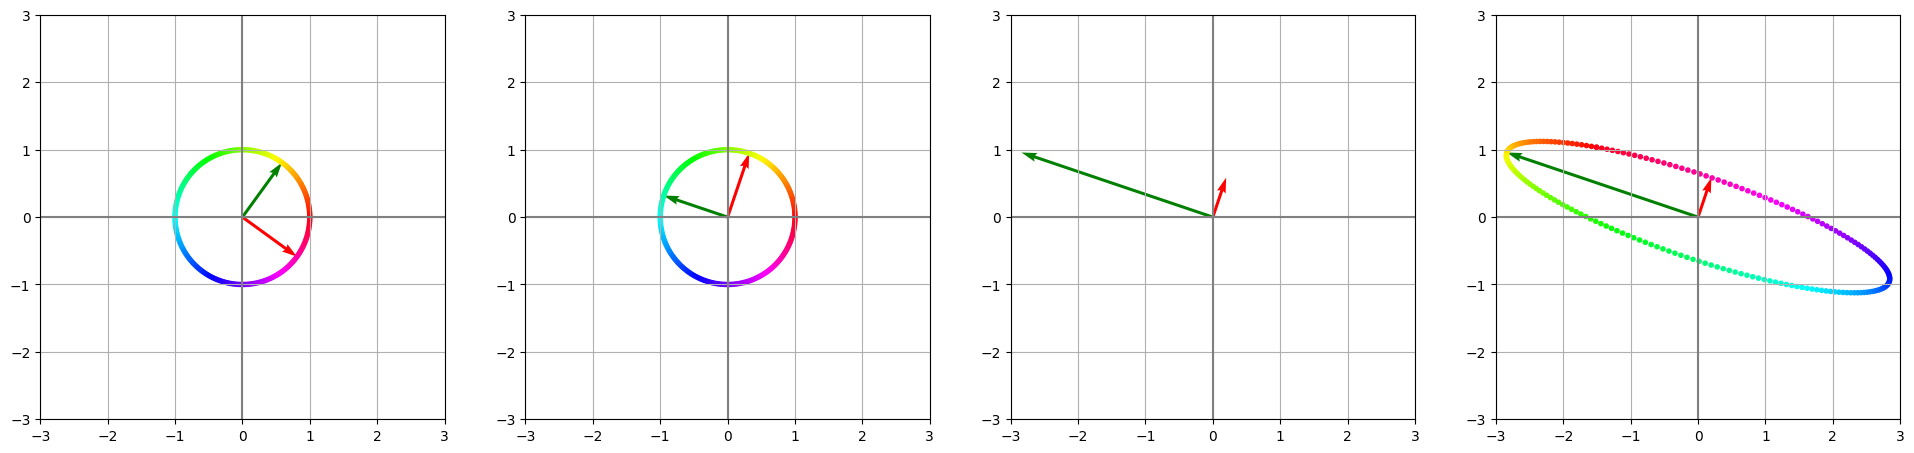

In [33]:
# Here is a matrix M
M = 5*(rng.random(size=(2,2))-0.5)

# Here is its SVD
H,s,CT = la.svd(M)

# Here is the list of points on the unit circle

t = np.linspace(0,1,200)
UnitCirclePoints = np.array([np.cos(2 * np.pi * t), np.sin(2*np.pi * t)])

# Now we'll draw three figures. 

fig,ax=LADS2DSquare(ncols=4,xlow=-3,xhigh=3)

# On the left we'll draw the unit circle and the rows of CT

ax[0].LADS2DDrawVector(CT[0],'green')
ax[0].LADS2DDrawVector(CT[1],'red')
ax[0].scatter(*UnitCirclePoints,marker=".",c=t,cmap=cm.hsv)

# In the next figure we'll draw the columns of H and the unit circle, to show that
# the columns of $H$ are an orthonormal basis. 

ax[1].LADS2DDrawVector(H[:,0],'green')
ax[1].LADS2DDrawVector(H[:,1],'red')
ax[1].scatter(*UnitCirclePoints,marker=".",c=t,cmap=cm.hsv)

# In the next figure we'll stretch the columns of $H$ by the entries of s.

ax[2].LADS2DDrawVector(s[0]*H[:,0],'green')
ax[2].LADS2DDrawVector(s[1]* H[:,1],'red')

# On the right we'll draw M applied to CT[0], CT[1], and the unit circle. You'll see that
# the columns of $H$ have been stretched to match the axes of the ellipse.

ax[3].LADS2DDrawVector(M@CT[0],'green')
ax[3].LADS2DDrawVector(M@CT[1],'red')
ax[3].scatter(*(M@UnitCirclePoints),marker=".",c=t,cmap=cm.hsv)

Run the code cell above a few times.  What you'll see is this:

>If $M$ is a $2\times 2$ matrix with SVD

$$
M = H@np.diag(s)@CT,
$$

>then $M$ sends the unit circle to the ellipse whose long axis points in the direction of $H[:,0]$ with radius $s[0]$, and whose short axis points in the direction of $H[:,1]$ with radius $s[1]$.  On the unit circle, the vectors $c[0]$ gets sent to the long axis $s_0 H[:,0]$, and $c[1]$ gets sent to the short axis $s_1 H[:,1]$. Also, $c[0]$ and $c[1]$ are perpendicular.


### Writing $Mv$ as a linear combination of the rows of $H$.

We'll continue to study the case of an $n\times n$ matrix $M$ with SVD

$$
M = H @ np.diag(s) @ CT.
$$
We'll continues to think of $H$ in terms of its columns,

$$
H = \begin{bmatrix}
| & & | \\
h_0 & \ldots  & h_{n-1} \\
| & & |
\end{bmatrix},
$$

and $CT$ in terms of its rows, 

$$
CT = \begin{bmatrix}
-- & c_0 & --\\
 & \vdots &  \\
-- & c_{n-1} & --\\
\end{bmatrix}.
$$

The entries of $s$ are 
$$
s=[s_0,\ldots,s_{n-1}].
$$ 

We know that $M$ sends $c_j$ to $s_j h_j$. What does $M$ to a general vector $v$? 

Remember that, since $c_0,\ldots, c_{n-1}$ is an orthonormal basis, we can use the dot product to find the coordinates of $v$ in the basis $c_0,\ldots,c_{n-1}$: the formula is

$$
 v = (c_0 \cdot v) * c_0 + \ldots (c_{n-1} \cdot v) * c_{n-1}.
$$

Since $M c_j = s_j* h_j$, we conclude that 

$$
\begin{align*}
Mv & =  (c_0\cdot v)* s_0* h_0 + \ldots + (c_{n-1}\cdot v) * s_{n-1} * h_{n-1}\\
   & = h_0 * s_0 *(c_0 \cdot v) + \ldots + h_{n-1}*  s_{n-1} * (c_{n-1} \cdot v).
\end{align*}
$$

In the second line, I've taken the unusual approach of writing the scalars $s_j$ and $(c_j \cdot v)$ after the vector $h_j$. Usually we've written the scalars first, for example $s_j (c_j \cdot v) h_j$. In this case I changed the order to match the order in the SVD.

We can write all this in Python notation: then 
$$
H = \begin{bmatrix}
| & & | \\
H[:,0] & \ldots  & H[:,n-1] \\
| & & |
\end{bmatrix},
$$

the rows of $CT$ are

$$
CT = \begin{bmatrix}
-- & CT[0] & --\\
 & \vdots &  \\
-- & CT[n-1] & --\\
\end{bmatrix}
$$

and the entries of $s$ are 
$$
s=[s[0],s[1],\ldots,s[n-1]].
$$ 

Then for any $nD$ vector $v$, we can compute $Mv$ as

````
M@v =  H[:,0] * s[0]* (CT[0]@ v) +  \ldots + H[:,n-1] * s[n-1]* (CT[n-1]@ v).
````

One thing to see here is 

>**Fact:** For every vector $v$, $M@v$ is a linear combination of the vectors $s_j*H[:,j]$ or $s_j h_j$.



In particular, if $s_j=0$, then you can't reach $h_j$. This leads to the notion of "rank" of a matrix.

### The "rank" of a matrix and the compact SVD: the case of a square matrix.

We'll continue to study the case a square matrix. Let $M$ be an $n\times n$ matrix with $SVD$

$$
M = H@np.diag(s)@CT.
$$

Let's write out the columns of $H$
$$
H = \begin{bmatrix}
| & & | \\
h_0 & \ldots  & h_{n-1} \\
| & & |
\end{bmatrix},
$$
the rows of $CT$

$$
CT = \begin{bmatrix}
-- & c_0 & --\\
 & \vdots &  \\
-- & c_{n-1} & --\\
\end{bmatrix},
$$
and the entries of $s$,
$$
s=[s_0,\ldots,s_{n-1}].
$$ 

The $s_j$ are non-negative and non-increasing: $s_0\geq s_1\geq\ldots.$  Eventually some of them could be zero. Suppose that $s_r$ is the last non-zero singular value, so that

$$
 s = [s_0,\ldots,s_{n-1}] = [s_0,\ldots,s_{r-1},0,\ldots,0].
$$

Then using our formula $Mc_j = s_j h_j$ above, we see that:

1. $M$ sends $c_j$ to $s_j h_j$ for $0 \leq j\leq  r-1$
1. $M$ sends $c_j$ to $0$ for $j\geq r$
1. $h_j$ is not in the image of $M$ for $j \geq r$.

By applying $M$ to vectors $v$, you can reach any vector in the span of $h_0,...,h_{r-1}$, but you can't reach any of the other $h_j$s for $j\geq r$. This number $r$ is important: it is called the "rank" of $M$.

>**Definition:** The **rank** of $M$ is the dimension of the image of $M$. It is also the number of non-zero singular values of $M$.

Let $Hc$ be the matrix containing the first $r$ columns of $H$, let $CTc$ be the matrix containing the first $r$ rows of $CT$, and let $sc$ be the vector containing the non-zero singular values of $M$. In Python you can accomplish that this way:
````
  H,s,C = la.svd(M)
  Hc = H[:,:r]
  sc = s[:r]
  CTc = CT[:r]
````

Or if you don't know the rank $r$ and want to find it:

````
H,s,C = la.svd(M)
r = len(np.where(~np.isclose(s,0.)[0])
sc = s[:r]
Hc = H[:,:r]
CTc = CT[:r]
````

>The **compact SVD** for $M$ is

````
  M = Hc @ np.diag(sc) @ CTc or (Hc*s) @ CTc
````

Here is an example.

In [34]:

# In this example we'll make a 5x5 matrix of rank 3. We'll extract its compact SVD 
# using the code above, and then we'll check that the compact SVD works for this matrkx


# The first few lines make a 5 by 5 matrix of rank 3. 

r0,r1,r2 = 10.* rng.random((3,5)) - 5.

r3 = r0 - r1 + 2 * r2
r4 = r0 + 3* r1 - r2

M = np.array([r0,r1,r2,r3,r4])

H,s,CT = la.svd(M)

print(f"The singular values of M are {s}")

r = len(np.where(~np.isclose(s,0.))[0])
print(f"The rank is {r}.")

# Now extract the pieces of the compact SVD

sc=s[:r]
Hc = H[:,:r]
CTc = CT[:r]

# This returns true if all the entries of M are very close to all the entries of the 
# compact SVD

print(np.allclose(M,Hc@ np.diag(sc)@CTc))
print(np.allclose(M,(Hc* sc)@CTc))

The singular values of M are [2.65132009e+01 1.02499701e+01 6.75612084e+00 2.31687461e-15
 3.40336584e-16]
The rank is 3.
True
True


# The SVD for all matrices, including non-square matrices

Now let's suppose that $M$ is not square: say $M$ is an $n\times k$ matrix, so it has $n$ rows and $k$ columns.  Let me rewrite the SVD fact from the begining. The "Singular Value Decompositon" or SVD of $M$ decomposes $M$ into a product of three matrices
$$
  M = H S CT \text{ or in Python } H@S@CT.
$$
Here:

1. $H$ is an $n\times n$ matrix whose columns are an orthonormal basis for $\mathbb{R}^n$.
2. $CT$ is a $k\times k$ matrix whose rows are an orthonormal basis for $\mathbb{R}^k$
3. $S$ is $n\times k$ matrix with:
   1. All the off-diagonal entries of $S$ are zero
   2. The diagonal entries of $S$ are non-negative and they appear in decreasing order.

Here we're doing something unusual and speaking about the diagonal of a non-square matrix. Two examples are

$$
S = \begin{bmatrix}
3 & 0 \\
0 & 1 \\
0 & 0 \end{bmatrix}
$$
and
$$
S = \begin{bmatrix}
3 & 0 & 0\\
0 & 1  & 0 
\end{bmatrix}
$$
If you think about it, you'll see that when $S$ not square, then it must have some non-zero rows or columns; it has at most $\min(n,k)$ non-zero entries.


It's most helpful to see how the "orthonormal basis to orthonormal basis" view of the SVD works for rectangular $M$. 

## The orthonormal basis to orthonormal basis view of the SVD: the general case

Just as in the square case, it's most helpful to think of $H$ in terms of its columns,
$$
H = \begin{bmatrix}
| & & | \\
h_0 & \ldots  & h_{n-1} \\
| & & |
\end{bmatrix};
$$
they are an orhonormal basis of $\mathbb{R}^n$.

The rows of $CT$ are

$$
CT = \begin{bmatrix}
-- & c_0 & --\\
 & \vdots &  \\
-- & c_{k-1} & --\\
\end{bmatrix},
$$
and they too are an orthonormal basis of $\mathbb{R}^k$, where $d=\min(n,k).$

We think of $S$ in terms of the array of its diagonal entries, 

$$
s=[s_0,\ldots,s_{d-1}].
$$ 

The analysis of $M$ goes almost the same as in the square case: the SVD tells you that $M=H@S@CT$ sends $c_j$ to $s_j h_j$.  The only problem is, how many values of $j$ are there? 

If $n>k$ then $H$ is bigger than $C$. We stop when we run out of rows of $C$, and the remaining $h_j$ are not in the image of $M$. When $k>n$ then $C$ is bigger than $H$, and we stop when we run out of columns of $H$, and the remaining $c_j$ go to zero.


Let's restate this concisely: let $d=min(k,n)$, and let the SVD of $M$ be $M = H@S@CT.

1. $M$ sends $c_j$, to $s_j h_j$ for $0\leq j \leq d-1.$
2. $M$ sends $c_j$ to zero for $d\leq j \leq k-1.$
3. The image of $M$ is the span of $h_0,\ldots h_{d-1}$, and the vectors $h_j$ are not in the image of $M$ for $d\leq j \leq n-1$.

Let's do two examples, one where $n<k$ and one where $n>k$.

In [35]:
# Here is a 3 by 5 matrix M
M = np.around(10*(rng.random(size=(3,5))-0.5),decimals=2)
print(M)

[[ 4.12 -0.    3.63  0.72  2.72]
 [-0.77  0.9   0.03 -0.15 -2.17]
 [-4.04 -0.78  0.54 -2.5   4.13]]


In [36]:
# here is its SVD
H,s,CT = la.svd(M)

print("The shape of H is ", H.shape)
print("The shape of s is ", s.shape)
print("The shape of CT is ",CT.shape)


The shape of H is  (3, 3)
The shape of s is  (3,)
The shape of CT is  (5, 5)


Notice that $s$ has three entries, because $3=\min(3,5)$. Now let's see what applying $M$ to the rows of $CT$ gives.

In [37]:

d = min(M.shape)
e = max(M.shape)
print("The smaller dimension of M is ", d)

print("")

for j in range(d):
    print(f"M sends the {j} row of CT to {np.around(M@CT[j],decimals=3)}." )
    print(f"s[{j}] times the {j} column of H is {np.around(s[j]*H[:,j],decimals=3)}.")
    if np.allclose(M@CT[j],s[j]*H[:,j]):
        print("Numpy says these are close to the same.")
    else:
        print("Numpy says these are NOT close enough.")
    print("")
    
for j in range(d,e):
    print(f"M sends the {j} row of CT to {np.around(M@CT[j],decimals=3)}.")
    

The smaller dimension of M is  3

M sends the 0 row of CT to [-4.306  0.196  5.112].
s[0] times the 0 column of H is [-4.306  0.196  5.112].
Numpy says these are close to the same.

M sends the 1 row of CT to [ 4.4   -2.004  3.783].
s[1] times the 1 column of H is [ 4.4   -2.004  3.783].
Numpy says these are close to the same.

M sends the 2 row of CT to [0.409 1.442 0.289].
s[2] times the 2 column of H is [0.409 1.442 0.289].
Numpy says these are close to the same.

M sends the 3 row of CT to [-0.  0.  0.].
M sends the 4 row of CT to [ 0. -0.  0.].


In [38]:
# Now let's try a matrix with more rows than columns. Here is a 4 by 2 matrix M
M = np.around(10*(rng.random(size=(4,2))-0.5),decimals=2)
print(M)

[[-2.19  1.8 ]
 [-4.76  4.74]
 [ 1.85  0.33]
 [-1.53 -4.73]]


In [39]:
# here is its SVD

H,s,CT = la.svd(M)

print("The shape of H is ", H.shape)
print("The shape of s is ", s.shape)
print("The shape of CT is ",CT.shape)



The shape of H is  (4, 4)
The shape of s is  (2,)
The shape of CT is  (2, 2)


Notice that $s$ has two entries, because $2 = \min(4,2)$. Now let's see what applying $M$ to the rows of $CT$ gives.

In [40]:

d = min(M.shape)
e = max(M.shape)

print("The smaller dimension of M is ", d)

print("")

for j in range(d):
    print(f"M sends the {j} row of CT to {np.around(M@CT[j],decimals=3)}." )
    print(f"s[{j}] times the {j} column of H is {np.around(s[j]*H[:,j],decimals=3)}.")
    if np.allclose(M@CT[j],s[j]*H[:,j]):
        print("Numpy says these are close to the same.")
    else:
        print("Numpy says these are NOT close enough.")
    print("")
    
    

The smaller dimension of M is  2

M sends the 0 row of CT to [-2.718 -6.593  0.763  3.061].
s[0] times the 0 column of H is [-2.718 -6.593  0.763  3.061].
Numpy says these are close to the same.

M sends the 1 row of CT to [ 0.806  1.288 -1.717  3.917].
s[1] times the 1 column of H is [ 0.806  1.288 -1.717  3.917].
Numpy says these are close to the same.



There is no way to get any non-zero linear combination of the $H[:,2]$ or $H[:,3]$, because we've used up the rows of $CT$!

### Reconstructing the matrix $M$ using the full SVD.

In the square case, we checked that 

````
  M = H@ S @ CT
````

and so far we haven't done that. In the non-square case, the challenge is to construct the matrix $S$ from the non-zero singular values. We'll do that several ways:

1. In this setion, we'll use the "full" SVD and construct a rectangular $n\times k$ diagonal matrix $S$ from the singular values
2. In the next section, we'll study the "trim" SVD where you make a $d\times d$ diagonal matrix $S$ from the singular values
3. Finally, we'll study again the "compact" SVD where you use the $r$ non-zero singular values to make an $r\times $r$ diagonal matrix $S$, and you also reduce the size of $H$ and $CT$.

For the full SVD we start with the list of singular values and then add as many non-zero rows or columns as we need. 

In [41]:
# Here is a random 5 by 7 matrix
M = -10 * rng.random((5,7))+5.

# Here is its SVD
H,s,CT = la.svd(M)

# d = min(5,7), in this case 5
d = len(s)
print("d = 5: ", d==5)
print("s = ",s)

# a 5\times 5 diagonal matrix with entries s
S0 = np.diag(s)

# in our 5 by 7 case, S needs 7 columns, so add two columns of zeros 
zeroes = np.zeros((5,2))
S = np.hstack((S0,zeroes))
print(S)

print(np.allclose(M, H @ S @ CT))

d = 5:  True
s =  [11.78134973  7.65143374  7.35307215  3.97852508  2.75140405]
[[11.78134973  0.          0.          0.          0.          0.
   0.        ]
 [ 0.          7.65143374  0.          0.          0.          0.
   0.        ]
 [ 0.          0.          7.35307215  0.          0.          0.
   0.        ]
 [ 0.          0.          0.          3.97852508  0.          0.
   0.        ]
 [ 0.          0.          0.          0.          2.75140405  0.
   0.        ]]
True


In [42]:
# Here is a random 6 by 4 matrix
M = -10 * rng.random((6,4))+5.

# Here is its SVD
H,s,CT = la.svd(M)

# d = min(6,4), in this case 4
d = len(s)
print("d = 4: ", d==4)
print("s = ",s)

# a 4\times 4 diagonal matrix with entries s
S0 = np.diag(s)

# in our 6 by 4 case, S needs 6 rows, so add two rows of zeroes
zeroes = np.zeros((2,4))
S = np.vstack((S0,zeroes))
print(S)

print(np.allclose(M, H @ S @ CT))

d = 4:  True
s =  [11.79877971  7.27818521  3.63653988  2.06900971]
[[11.79877971  0.          0.          0.        ]
 [ 0.          7.27818521  0.          0.        ]
 [ 0.          0.          3.63653988  0.        ]
 [ 0.          0.          0.          2.06900971]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
True


As in the square case, it's inefficient and unnecessary to make the matrix $S$ to reconstruct $M$. Instead you can write

````
d = min(M.shape)
M = (H[:,:d]*s) @ CT[:d]
````

In [43]:
# Here is a random 5 by 7 matrix
M = -10 * rng.random((5,7))+5.

# Here is its SVD
H,s,CT = la.svd(M)

# d = min(5,7), in this case 5
d = len(s)
print("d = 5: ", d==5)
print("s = ",s)

print(np.allclose(M, (H[:,:d]*s) @ CT[:d]))

# Here is a random 6 by 4 matrix
M = -10 * rng.random((6,4))+5.

# Here is its SVD
H,s,CT = la.svd(M)

# d = min(6,4), in this case 4
d = len(s)
print("d = 4: ", d==4)
print("s = ",s)

print(np.allclose(M, (H[:,:d]*s) @ CT[:d]))

d = 5:  True
s =  [10.90338091  9.67943195  6.32834848  3.56414286  2.27261325]
True
d = 4:  True
s =  [10.83085057  8.26777351  6.56994138  2.814787  ]
True


Notice that we only used the first $d$ columns of $H$ and the first $d$ rows of CT: this is the key idea of the "Trim" SVD.

## The Trim SVD

Let $M$ be an $n\times k$ matrix. We've seen that if $n\neq k$, then the SVD tells us that $M$ is really focused on the first $d$ vectors of a basis, where $d=\min(n,k)$.  Let $M = H @ S @ CT$ be the "full matrices" version of the SVD we've been studying all along.

To make the trim version of the SVD: 

1. Take the first $d$ columns of $H$ to make an $n \times d$ matrix $Hd$ or `H[:,:d]`.
2. Take the $d$ singular values to make an $d\times d$ diagonal matrix $Sd$. 
3. Take the first $d$ rows of $CT$ to make a $d\times k$ matrix $CdT$ or $CT[:d]$.

Then the "square diagonal" version of the SVD says that

````
M = Hd @ Sd @ CdT = H[:,:d] @ np.diag(s) @ CT[:d] = (H[:,:d]*s) @ CT[:d].
````

Write $Hd$ in terms of its columns: 
$$
Hd = \begin{bmatrix}
| & & | \\
h_0 & \ldots  & h_{d-1} \\
| & & |
\end{bmatrix},
$$
then the columsn of $Hd$ are an orthonormal frame. 

Write $CdT$ in terms of its rows:

$$
CDT = \begin{bmatrix}
-- & c_0 & --\\
 & \vdots &  \\
-- & c_{d-1} & --\\
\end{bmatrix},
$$
and they too are an orthonormal frame.

Let $s$ be the vector of singular values: 
$$
s=[s_0,\ldots,s_{d-1}].
$$ 

Then:

> For $0\leq j \leq d-1$, $M$ sends $c_j$ to $s_j h_j$. 

We can write the effecto $M$ on any vector:
> If $v$ is any $k$-dimensional vector, then 
$$
Mv = h_0 s_0 (c_0 \cdot v) + \ldots + h_{d-1} s_{d-1} (c_{d-1} \cdot v).
$$

>In Python notation,
$$
M@v = HD[:,0] * s[0] * (CDT[0]@v) + \ldots + HD[:,d-1] * s[d-1] * (CDT[d-1] @ v)
$$

Python gives you direct access to the Trim SVD by setting `full_matrices=false`

In [44]:
# Here is a 25 by 30 matrix M

print("25 by 30 example")
M = 50* rng.random((25,30)) - 25

# Here is the full SVD
H,s,CT = la.svd(M)

# Here is the compact SVD
Hd,sd,CdT = la.svd(M,full_matrices=False)

d = len(sd)

print("H[:,:d] == Hd:", np.allclose(H[:,:d], Hd))
print("CT[:d] == CdT:", np.allclose(CT[:d], CdT))
print("s[:d] == sd", np.allclose(s[:d],s))


# Let's check the shape of these matrices to see that we have the "trim" SVD

print("Hd should have 25 rows and 25 columns: ",Hd.shape)
print("sd should have length 25: ", len(sd))
print("CdT should have 25 rows and 30 columns: ", CdT.shape)

print("The trim SVD worked: ",np.allclose(M,(Hd*sd)@CdT))

# Here is a 50 by 35 matrix M

print("50 by 35 example")

M = 50* rng.random((50,35)) - 25
# Here is the full SVD

H,s,CT = la.svd(M)

# Here is the compact SVD
Hd,sd,CdT = la.svd(M,full_matrices=False)

d = len(sd)

print("H[:,:d] == Hd:", np.allclose(H[:,:d], Hd))
print("CT[:d] == CdT:", np.allclose(CT[:d], CdT))
print("s[:d] == sd", np.allclose(s[:d],s))


# Let's check the shape of these matrices to see that we have the "trim" SVD

print("Hd should have 50 rows and 35 columns: ",Hd.shape)
print("sd should have length 35: ", len(sd))
print("CdT should have 35 rows and 35 columns: ", CdT.shape)

print("The trim SVD worked: ",np.allclose(M,(Hd*sd)@CdT))


H,s,CT = la.svd(M,full_matrices=False)

# Let's check the shape of these matrices to see that we have the "trim" SVD

print("H should have 50 rows and 35 columns: ",H.shape)
print("s should have length 35: ", len(s))
print("CT should have 35 rows and 35 columns: ", CT.shape)

print("The trim SVD worked: ",np.allclose(M,(H*s)@CT))

25 by 30 example
H[:,:d] == Hd: True
CT[:d] == CdT: True
s[:d] == sd True
Hd should have 25 rows and 25 columns:  (25, 25)
sd should have length 25:  25
CdT should have 25 rows and 30 columns:  (25, 30)
The trim SVD worked:  True
50 by 35 example
H[:,:d] == Hd: True
CT[:d] == CdT: True
s[:d] == sd True
Hd should have 50 rows and 35 columns:  (50, 35)
sd should have length 35:  35
CdT should have 35 rows and 35 columns:  (35, 35)
The trim SVD worked:  True
H should have 50 rows and 35 columns:  (50, 35)
s should have length 35:  35
CT should have 35 rows and 35 columns:  (35, 35)
The trim SVD worked:  True


## The compact SVD


In the "Trim SVD" we only $d=min(n,k)$ singular values. As we learned in the square case, we only need the non-zero singular values. Using only those leads to the "compact" SVD.

Let $M$ be an $n\times k$ matrix, and let $d=min(n,k)$. Suppose that we've set

````
H,s,CT = la.svd(M),
````

so that
$$
M = H[:,:d] @ np.diag(s) @ CT[:d] = (H[:,:d] *s) @ CT[:d] 
$$

Let $r$ be the number of *non-zero* singular values, so $s = [s_0,\ldots,s_{r-1},0,\ldots,0].$ 

> The **compact SVD** of $M$ is
````
M = H[:,:r] @ np.diag(s[:r]) @  CT[:r] or (H[:,:r]*s[:r]) @  CT[:r]
````

Let's use name the columns of $H$
$$
H = \begin{bmatrix}
| & & | \\
h_0 & \ldots  & h_{n-1} \\
| & & |
\end{bmatrix}
$$
and the rows of $CT$
$$
CT = \begin{bmatrix}
-- & c_0 & --\\
 & \vdots &  \\
-- & c_{k-1} & --\\
\end{bmatrix},
$$
Using our formula $Mc_j = s_j h_j$, we see that:

1. $M$ sends $c_j$ to $s_j h_j$ for $0 \leq j\leq  r-1$
1. $M$ sends $c_j$ to $0$ for $j\geq r$
1. $h_j$ is not in the image of $M$ for $j \geq r$.

By applying $M$ to vectors $v$, you can reach any vector in the span of $h_0,...,h_{r-1}$, but you can't reach any of the $h_j$s for $j\geq r$. Just as in the square case, this number $r$ is important: it is called the "rank" of $M$.

>**Definition:** The **rank** of $M$ is the dimension of the image of $M$. It is also the number of non-zero singular values of $M$.

You can use the same Python code as in the square case to get the compact SVD: if you set

````
H,s,C = la.svd(M)
r = len(np.where(~np.isclose(s,0.)[0])
sc = s[:r]
Hc = H[:,:r]
CTc = CT[:r]
````
then the compact SVD of $M$ is

````
  M = Hc @ np.diag(sc) @ CTc or (Hc*s) @ CTc
````

Here is an example.

In [45]:


print("25 by 30 example")
M = 50* rng.random((20,30)) - 25

# Let's add some rows 
r0 = M[5] + 7* M[9]
r1 = M[10] - M[11] + M[19]
r2 = M[0] + M[2] + M[4]

M = np.vstack((M,np.array([r0,r1,r2])))

# Here is the compact SVD
H,s,CT = la.svd(M,full_matrices=False)

# Get the rank, and then make the matrices of the compact SVD
r = len(np.where(~np.isclose(s,0.))[0])
print("The rank is ",r)

Hc = H[:,:r]
CTc = CT[:r]
sc = s[:r]

(Hc*sc) @ CTc
print("The compact SVD worked: ",np.allclose(M,(Hc*sc)@CTc))


25 by 30 example
The rank is  20
The compact SVD worked:  True


#### Do it:

1. Make a pretty big square matrix (at least 10 by 10) $M$. You can generate it randomly if you want

In [49]:
M = np.around(10*(rng.random(size=(10,10))-0.5),decimals=1)
print(M)

[[ 3.6 -0.5 -2.3 -4.6  4.8 -2.3 -1.8 -4.   0.6 -2.7]
 [-3.2 -4.8 -2.6 -4.9 -0.6  4.1 -4.  -4.2 -3.2  4.5]
 [-4.6 -4.9  0.4  1.3  3.   3.7  2.3 -0.5 -0.3 -2.9]
 [ 2.1 -3.9  3.9 -2.2  3.3 -1.3  1.4 -1.4  1.3  2.7]
 [ 3.3 -0.6 -1.8  1.3  2.5  2.7  0.2  4.9 -1.2 -0.6]
 [ 4.9 -1.4 -0.7 -4.  -1.5  3.2  4.4  2.9  0.1 -3.6]
 [-3.4  3.6 -1.4  0.8  2.3 -2.   4.7  4.4 -0.6 -1.9]
 [ 2.1 -3.2  1.2  3.7  2.  -4.8  4.6 -2.2 -5.  -0.6]
 [ 1.8  2.6  2.2 -1.7  1.7  2.1 -2.   3.2  2.   3.6]
 [-0.7 -4.2 -4.6 -0.7  1.3  1.6  0.8  3.6 -3.5  3.1]]


#### Leave for Grader: 

#### Do it: 

Compute the svd of your matrix so that $M = H @ np.diag(s) @ CT$. Check that the columns of $H$ are orthonormal, and check that the columns of $CT$ are orthonormal. [Hint: if $B$ is a matrix, what calculation checks that its columns are orthonormal?]

In [51]:
# Put your work in this code cell. 
H, s, CT = np.linalg.svd(M)
S = np.diag(s)
M_reconstructed = H @ S @ CT

HTH = H.T @ H
print("H.T @ H:\n", np.round(HTH, decimals=1))
CTT_CT = CT @ CT.T
print("CT @ CT.T:\n", np.round(CTT_CT, decimals=1))


H.T @ H:
 [[ 1. -0.  0. -0.  0. -0.  0. -0.  0.  0.]
 [-0.  1. -0. -0.  0. -0.  0.  0. -0. -0.]
 [ 0. -0.  1.  0.  0.  0. -0. -0.  0.  0.]
 [-0. -0.  0.  1. -0.  0.  0.  0. -0.  0.]
 [ 0.  0.  0. -0.  1.  0.  0.  0. -0.  0.]
 [-0. -0.  0.  0.  0.  1. -0.  0.  0. -0.]
 [ 0.  0. -0.  0.  0. -0.  1.  0. -0.  0.]
 [-0.  0. -0.  0.  0.  0.  0.  1. -0.  0.]
 [ 0. -0.  0. -0. -0.  0. -0. -0.  1.  0.]
 [ 0. -0.  0.  0.  0. -0.  0.  0.  0.  1.]]
CT @ CT.T:
 [[ 1. -0.  0.  0.  0.  0. -0.  0.  0.  0.]
 [-0.  1.  0.  0.  0. -0.  0.  0. -0. -0.]
 [ 0.  0.  1. -0.  0. -0. -0.  0.  0. -0.]
 [ 0.  0. -0.  1. -0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -0.  1.  0.  0. -0.  0.  0.]
 [ 0. -0. -0.  0.  0.  1. -0. -0. -0.  0.]
 [-0.  0. -0.  0.  0. -0.  1. -0.  0.  0.]
 [ 0.  0.  0.  0. -0. -0. -0.  1. -0. -0.]
 [ 0. -0.  0.  0.  0. -0.  0. -0.  1.  0.]
 [ 0. -0. -0.  0.  0.  0.  0. -0.  0.  1.]]


#### Leave for grader:

#### Do it: 
Check that the $M = H np.diag(s) CT.$

In [54]:
# put your work in this code cell.
difference = np.round(M - M_reconstructed, decimals=10)
max_diff = np.max(np.abs(difference))
print("\nReconstructed M:\n", np.round(M_reconstructed, decimals=0))
print("\nDifference M - H @ diag(s) @ CT:\n", difference)
print("\nMax absolute difference:", max_diff)
if max_diff < pow(1,-10):
    print("\n The reconstruction is accurate: M ≈ H @ diag(s) @ CT")
else:
    print("\n The reconstruction is not accurate enough.")


Reconstructed M:
 [[ 4. -1. -2. -5.  5. -2. -2. -4.  1. -3.]
 [-3. -5. -3. -5. -1.  4. -4. -4. -3.  4.]
 [-5. -5.  0.  1.  3.  4.  2. -1. -0. -3.]
 [ 2. -4.  4. -2.  3. -1.  1. -1.  1.  3.]
 [ 3. -1. -2.  1.  3.  3.  0.  5. -1. -1.]
 [ 5. -1. -1. -4. -1.  3.  4.  3.  0. -4.]
 [-3.  4. -1.  1.  2. -2.  5.  4. -1. -2.]
 [ 2. -3.  1.  4.  2. -5.  5. -2. -5. -1.]
 [ 2.  3.  2. -2.  2.  2. -2.  3.  2.  4.]
 [-1. -4. -5. -1.  1.  2.  1.  4. -3.  3.]]

Difference M - H @ diag(s) @ CT:
 [[-0.  0.  0.  0. -0.  0. -0.  0.  0.  0.]
 [-0. -0.  0. -0.  0.  0.  0. -0. -0.  0.]
 [ 0.  0. -0.  0. -0.  0. -0.  0. -0.  0.]
 [-0.  0. -0. -0. -0.  0. -0.  0. -0.  0.]
 [-0.  0. -0.  0. -0.  0. -0.  0.  0.  0.]
 [-0.  0.  0.  0. -0.  0. -0.  0.  0.  0.]
 [ 0.  0. -0.  0. -0.  0.  0.  0. -0.  0.]
 [-0.  0. -0. -0. -0.  0.  0.  0.  0.  0.]
 [ 0. -0.  0.  0.  0. -0.  0. -0. -0. -0.]
 [-0.  0. -0. -0. -0.  0. -0.  0. -0.  0.]]

Max absolute difference: 0.0

 The reconstruction is accurate: M ≈ H @ diag(s) @ CT

#### Leave for grader: 


#### Do it:
Make a new large random matrix N, at least 10 by 10. Add 3 rows to $N$ by these steps:

1. Let r0 be some linear combination of rows of $N$
1. Let r1 be some other linear combination of rows of $N$
1. Let r2 be some third linear combination of rows of $N$
1. Set `M = np.vstack((N,np.array([r0,r1,r2])))`

In [55]:
# you can put your code in this cell
rng = np.random.default_rng(seed=123)
N = np.around(10 * (rng.random(size=(10, 10)) - 0.5), decimals=1)
              
coefficient_r0 = rng.random(10)
coefficient_r1 = rng.random(10)
coefficient_r2 = rng.random(10)
r0 = np.dot(coefficient_r0, N)
r1 = np.dot(coefficient_r1, N)
r2 = np.dot(coefficient_r2, N)
M = np.vstack((N, np.array([r0, r1, r2])))

print("Original matrix N:\n", N)
print("\nNew rows:\n", np.array([r0, r1, r2]))
print("\nMatrix M with added rows:\n", M)
print("\nShape of M:", M.shape)

Original matrix N:
 [[ 1.8 -4.5 -2.8 -3.2 -3.2  3.1  4.2 -2.2  3.2  3.9]
 [ 0.1 -2.6  3.2 -2.9  2.4  1.3  4.3 -2.7  3.   0.2]
 [-2.7 -3.3 -0.   0.8 -3.2 -4.9 -0.3  2.3  4.2  1.3]
 [ 4.2  3.6 -2.8  3.7  2.3 -2.2  3.   3.7 -2.   0.3]
 [-4.3  0.8 -2.6  2.6 -3.3 -1.9 -4.9 -4.7 -0.  -0.3]
 [-3.7 -2.4 -5.  -1.2  0.8 -0.7  3.4  1.2 -2.3  3.1]
 [-0.   2.6  0.7 -0.6 -1.  -4.8 -0.3  1.2  4.5 -0.6]
 [-0.1  0.2 -0.9  0.8 -4.3 -0.1  1.1  2.4 -0.7 -2. ]
 [-4.9  2.6 -4.2 -0.1 -2.   3.4  4.5 -1.8  4.  -1.6]
 [ 3.1  3.   1.6 -2.7 -3.6 -0.8 -3.5  3.7 -3.2 -4.7]]

New rows:
 [[-7.448398   -2.42545889 -7.01891071 -2.40333418 -7.78443292 -5.67793174
   7.41304699  0.31520886 11.16931282  2.42498116]
 [-3.95408297 -0.02623531 -7.12219119 -2.40711287 -8.39260017 -0.6408963
   7.04301619 -0.57231148  7.48675508  0.19565123]
 [ 0.82127994 -3.17275395 -4.99933198 -1.71103897 -6.6460204  -3.03913575
   9.00836779  1.97070284  8.0733626   2.74553831]]

Matrix M with added rows:
 [[ 1.8        -4.5        -2.8    

#### Leave for grader.

#### Do it: 
Find the rank $r$ and the compact SVD of $M$. Print the rank, and if 
`Hc`, `sc`, and `CTc` are the matrices you found in the compact SVD, check that 

$$
  M = (Hc * sc) @ CTc.
$$

In [61]:
# You can put your work in this code cell.

rank = np.linalg.matrix_rank(M)
print("Rank of M:", rank)

threshold = pow(1,-10)
r = np.sum(s > threshold)

Hc = H[:, :r]
sc = s[:r]
CTc = CT[:r, :]

M_reconstructed = (Hc * sc) @ CTc
M_reconstructed = np.vstack((N, np.array([r0, r1, r2])))
diff = np.round(M - M_reconstructed, decimals=1)
max_diff = np.max(np.abs(diff))

print("\n Compact SVD reconstruction difference:\n", diff)
print("\n Max absolute difference:", max_diff)

if max_diff < pow(1,-10):
    print("\n Verified: M ≈ (Hc * sc) @ CTc using compact SVD.")
else:
    print("\n M reconstruction from compact SVD not accurate enough.")

Rank of M: 10

 Compact SVD reconstruction difference:
 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]

 Max absolute difference: 0.0

 Verified: M ≈ (Hc * sc) @ CTc using compact SVD.


#### Leave for Grader